In [1]:
import pandas as pd

In [3]:
!pip install nsepy
from nsepy import get_history as gh
import datetime as dt

  Preparing metadata (setup.py) ... done
  Created wheel for nsepy: filename=nsepy-0.8-py3-none-any.whl size=36057 sha256=faf0ce98517ac334dbb84da6e9b28002efc1e308467d70e1a28970e30426debe
  Stored in directory: /root/.cache/pip/wheels/ba/d6/a0/a2c830ea2a083f15d9790732c1908625dd6314a02f09a92130
Successfully built nsepy


In [7]:
!pip install yfinance

import yfinance as yf
import datetime as dt

start = dt.datetime(2021,9,1)
end = dt.datetime(2022,2,4)


stk_data = yf.download('RELIANCE.NS', start=start, end=end)


/tmp/ipykernel_1692/1411886767.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stk_data = yf.download('RELIANCE.NS', start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [8]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data.to_csv("Tatacoffee13_21.csv")

In [9]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[["Close"]])
print("Len:",data1.shape)

Len: (107, 1)


In [11]:
"""from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(data1, order=(1,1,1))
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(stk_data), len(stk_data)-1)
print(y_pred)
from stockFunctions import rmsemape
rmsemape(stkk,predicted_stock_price_test_oriP["Open"])"""

'from statsmodels.tsa.arima.model import ARIMA\nmodel = ARIMA(data1, order=(1,1,1))\nmodel_fit = model.fit()\n# make prediction\ny_pred= model_fit.predict(len(stk_data), len(stk_data)-1)\nprint(y_pred)\nfrom stockFunctions import rmsemape\nrmsemape(stkk,predicted_stock_price_test_oriP["Open"])'

In [14]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA

orders=[(1,0,2),(1,0,1),(2,0,1),(1,0,1)]
orderslist=[]
rscorelist=[]

for i in orders:
    orderslist.append(i)
    model = ARIMA(data1, order=i)
    model_fit = model.fit()
    y_pred= model_fit.predict(0, len(data1)-1)
    print(y_pred)

    rmse = np.sqrt(mean_squared_error(data1, y_pred))
    mape = mean_absolute_percentage_error(data1, y_pred)
    print(f"RMSE-Testset: {rmse}")
    print(f"MAPE-Testset: {mape}")
    rscorelist.append((rmse, mape))

[0.37693359 0.02559204 0.08398073 0.2855419  0.36645409 0.3806445
 0.3546865  0.34050008 0.2299024  0.21909446 0.25149103 0.35722426
 0.28028169 0.27277008 0.30399037 0.35921232 0.48259187 0.46794215
 0.54110988 0.59724597 0.54927034 0.5234807  0.53749408 0.60824077
 0.72080977 0.61562118 0.62464406 0.84480624 0.81461813 0.82011382
 0.88324823 0.89652849 0.90524683 0.95561774 0.89156475 0.71999401
 0.72940389 0.69493553 0.81384589 0.75381642 0.6766967  0.5508731
 0.55553732 0.49184799 0.45068502 0.48788283 0.5000745  0.53731901
 0.59724805 0.60588121 0.68052564 0.65206886 0.51708686 0.40180463
 0.4301989  0.21418818 0.24494198 0.19945813 0.48661237 0.33913969
 0.35892194 0.30485564 0.42630999 0.47218289 0.30420041 0.19674497
 0.25091028 0.33938425 0.4167438  0.41667921 0.30595954 0.23959113
 0.23413733 0.30412156 0.17505839 0.02880113 0.10768149 0.24108367
 0.23550252 0.23707343 0.23399934 0.29222977 0.30413787 0.20745027
 0.22084559 0.30710248 0.42206609 0.4424582  0.32061117 0.354193

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


[0.35851449 0.02363349 0.07242308 0.25724989 0.34493319 0.36857022
 0.35865822 0.33890601 0.2430398  0.21918373 0.25169961 0.3366944
 0.28516768 0.26738474 0.3081929  0.34189681 0.4722544  0.45791449
 0.53550666 0.59091724 0.54957781 0.53118536 0.53929222 0.60175614
 0.70847976 0.62269437 0.62858758 0.83244514 0.80678443 0.82319252
 0.88793633 0.89363508 0.91225445 0.95556565 0.90406631 0.74332051
 0.74522623 0.70414075 0.80381636 0.76442744 0.68241252 0.5806421
 0.55571545 0.50911046 0.44889384 0.49623258 0.49053656 0.53794083
 0.58751798 0.60597786 0.67183184 0.65781401 0.52911895 0.4260481
 0.43184169 0.23717552 0.24286431 0.21263699 0.44280342 0.3552886
 0.3382047  0.33559322 0.38954702 0.48502453 0.29458743 0.23135893
 0.2380305  0.3351883  0.39261056 0.41868109 0.30889509 0.25523685
 0.23346315 0.29675063 0.18009105 0.04351909 0.10668436 0.21880917
 0.22323327 0.23233395 0.23353429 0.28107266 0.30007304 0.21003759
 0.22340401 0.29588548 0.40247113 0.4336334  0.32855011 0.35664111

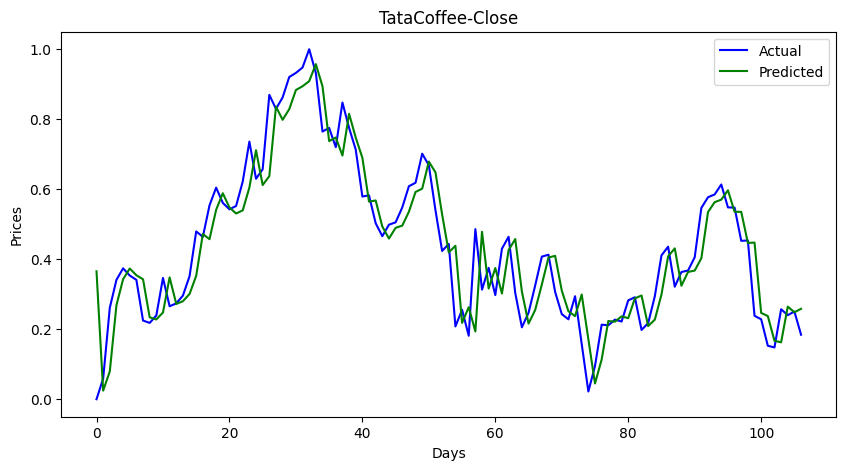

In [15]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","TataCoffee-Close","Days","Prices")

In [16]:
len(data1)

107

In [17]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [18]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

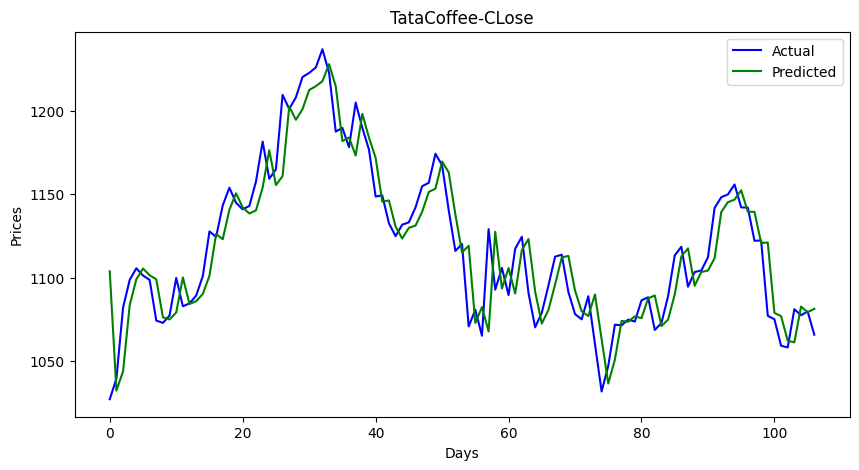

In [19]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-CLose","Days","Prices")

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

rmse_val = np.sqrt(mean_squared_error(actual_stock_price_test_oriA, predicted_stock_price_test_oriP))
mape_val = mean_absolute_percentage_error(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

print(f"RMSE: {rmse_val}")
print(f"MAPE: {mape_val}")

RMSE: 19.581498379366547
MAPE: 0.013035630058223396


In [22]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [23]:
forecast

array([0.19635167, 0.20773848, 0.21835832, 0.22826285])

In [24]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [25]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [26]:
forecast_stock_price_test_oriF

,Closefore
0,1068.140938
1,1070.537788
2,1072.773195
3,1074.858034
